In [2]:
import pandas as pd
df = pd.read_csv("Superstore.csv")
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [3]:
df.info()
df.columns
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [4]:
df.duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])   
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9983 non-null   float64       
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [7]:
df["Delivery Days"] = df["Ship Date"] - df["Order Date"]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype          
---  ------         --------------  -----          
 0   Row ID         9994 non-null   int64          
 1   Order ID       9994 non-null   object         
 2   Order Date     9994 non-null   datetime64[ns] 
 3   Ship Date      9994 non-null   datetime64[ns] 
 4   Ship Mode      9994 non-null   object         
 5   Customer ID    9994 non-null   object         
 6   Customer Name  9994 non-null   object         
 7   Segment        9994 non-null   object         
 8   Country        9994 non-null   object         
 9   City           9994 non-null   object         
 10  State          9994 non-null   object         
 11  Postal Code    9983 non-null   float64        
 12  Region         9994 non-null   object         
 13  Product ID     9994 non-null   object         
 14  Category       9994 non-null   object         
 15  Sub-

In [8]:
df["Delivery Days"].max()   # Max Delivery Days
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)  # Which region has the highest sales
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)  # WHich Category gains the most profit
df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(5)  # Top 5 sub caategory sales
df.groupby("State")["Profit"].sum().sort_values(ascending=True).head(1)  # top 1 stae with highest loss
df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5) # Top 5 Customer 
df.groupby("Segment")["Profit"].mean().sort_values(ascending=False) # Which segment gains the most profit
df.groupby("Ship Mode")["Delivery Days"].mean().sort_values(ascending=False) # which ship mode takes the highest delivcery days 
df.groupby("Category").agg({
    "Sales" : "sum",
    "Profit" : "sum"
})   # to check sales , profit on the basis of category
df.groupby("Region").agg({
    "Sales" : "sum"
    ,"Profit" : "mean"
})     # region wise total sales and average profit

df.groupby("Category")["Sales"].agg(["sum","mean","min","max"])  # category wise sales (total,avg,max,min)
df.groupby(["Category","Region"])["Sales"].sum()  # Category and region wise total sales
df.groupby(["Category","Region"]).agg({
    "Sales" : "sum",
    "Profit" : "sum"
})   # Catefgory and region wise total sale and profit




Sales      Profit
Category        Region                          
Furniture       Central  163797.1638  -2871.0494
                East     208291.2040   3046.1658
                South    117298.6840   6771.2061
                West     252612.7435  11504.9503
Office Supplies Central  167026.4150   8879.9799
                East     205516.0550  41014.5791
                South    125651.3130  19986.3928
                West     220853.2490  52609.8490
Technology      Central  170416.3120  33697.4320
                East     264973.9810  47462.0351
                South    148771.9080  19991.8314
                West     251991.8320  44303.6496

In [9]:
df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)  # Top 10 state by sales
df.groupby("City")['Sales'].sum().sort_values(ascending=False).head(10)  # "" city
df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=True).head(10)  # Sub-category which which made loss
df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)  # which product made the good revenue
df.groupby("Product Name")["Profit"].sum().sort_values(ascending=True).head(10)  # Product that generate loss
df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False).head(10) # customer who generate profit
df.groupby("Category")["Discount"].mean().sort_values(ascending=False)  #which region has the highest average discount
df[(df["Discount"] > 0) & (df["Profit"] < 0)][["Order ID","Customer Name","Category","Discount","Profit"]]   # gain profit still in loss
df[(df["Sales"] > 1000) & (df["Profit"] > 0)][["Order ID","Customer Name","Product Name","Sales","Profit"]]
df[(df["Sales"] > 5000) | (df["Discount"] >= 0.5)][["Customer Name","Sales","Discount"]]

,Customer Name,Sales,Discount
14,Harold Pawlan,68.810,0.8
15,Harold Pawlan,2.544,0.8
27,Tracy Blumstein,3083.430,0.5
28,Tracy Blumstein,9.618,0.7
32,Tracy Blumstein,6.858,0.7
...,...,...,...
9870,Erin Ashbrook,22.428,0.7
9877,Brad Eason,8.700,0.7
9903,Darren Powers,25.128,0.6
9920,Muhammed Yedwab,22.386,0.8




# Visualization

In [10]:
import matplotlib.pyplot as plt


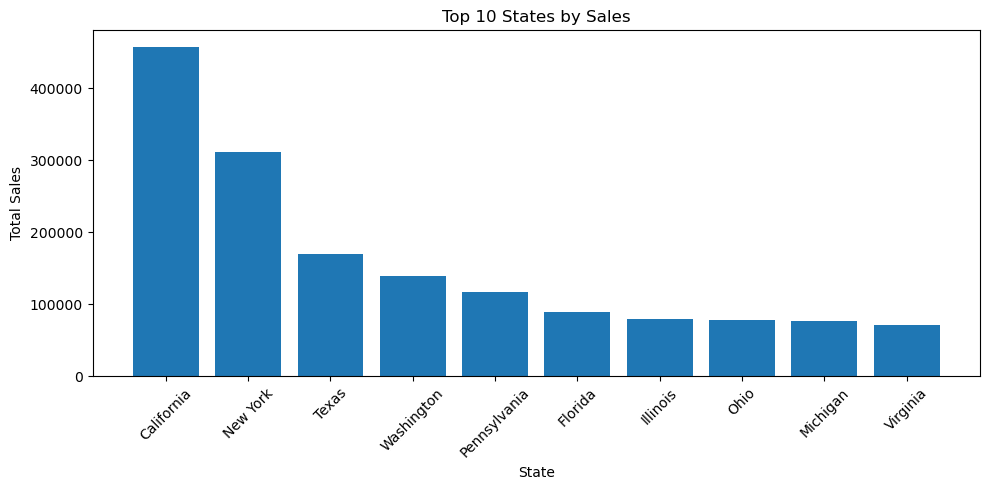

In [11]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top_states.index, top_states.values)

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

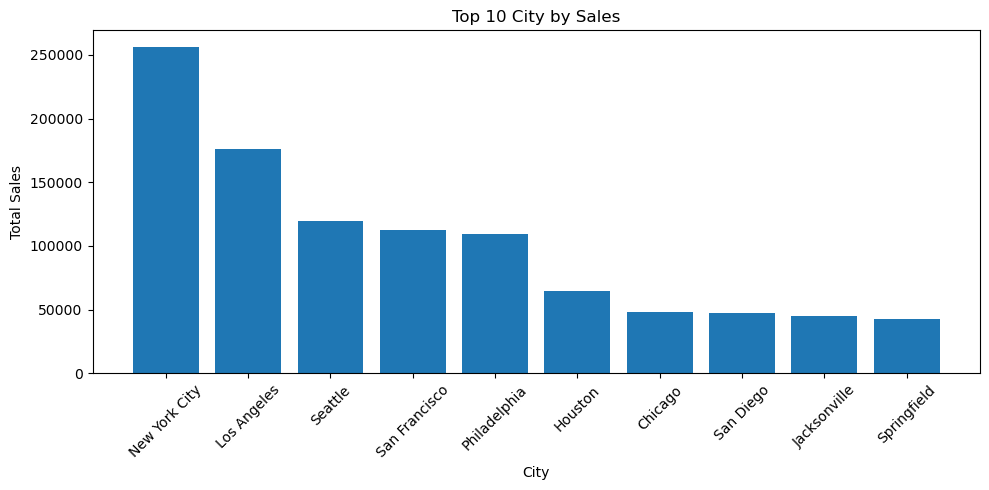

In [12]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top_cities.index, top_cities.values)

plt.title("Top 10 City by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

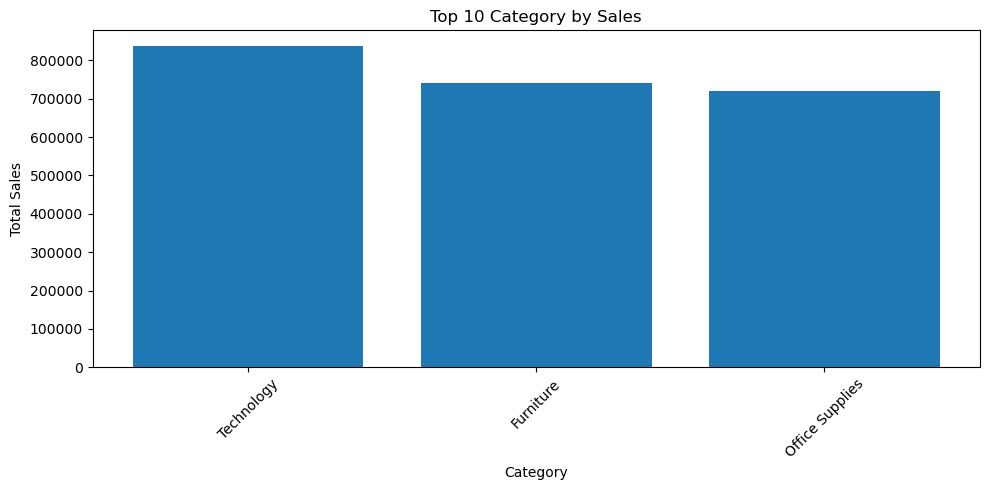

In [13]:
category_wise_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(category_wise_sales.index, category_wise_sales.values)

plt.title("Top 10 Category by Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

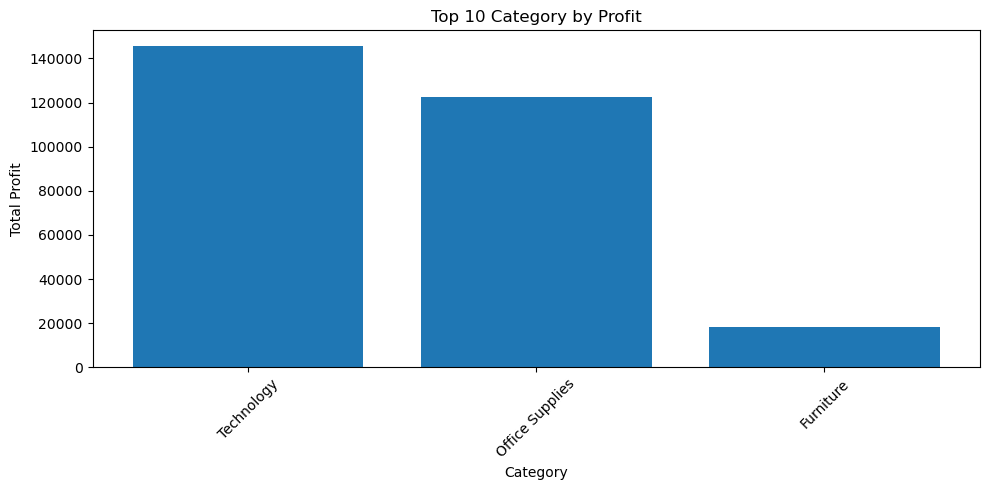

In [14]:
Category_wise_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.bar(Category_wise_profit.index, Category_wise_profit.values)

plt.title("Top 10 Category by Profit")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

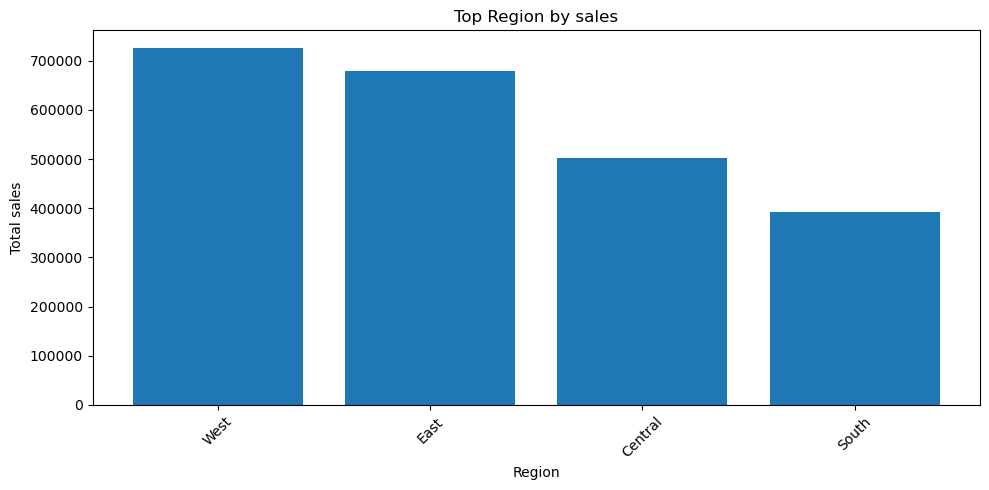

In [15]:
region_wise_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.bar(region_wise_sales.index, region_wise_sales.values)

plt.title("Top Region by sales")
plt.xlabel("Region")
plt.ylabel("Total sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

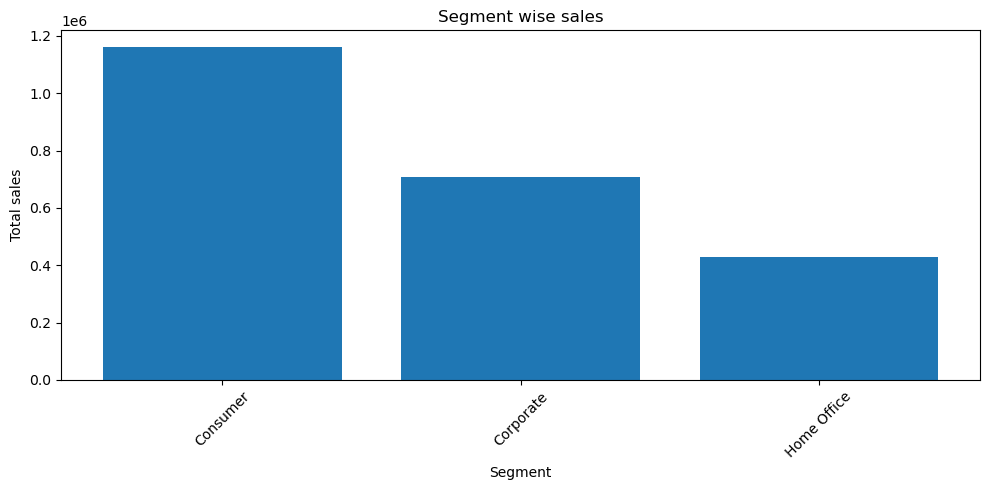

In [16]:
segment_wise_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.bar(segment_wise_sales.index, segment_wise_sales.values)

plt.title("Segment wise sales")
plt.xlabel("Segment")
plt.ylabel("Total sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

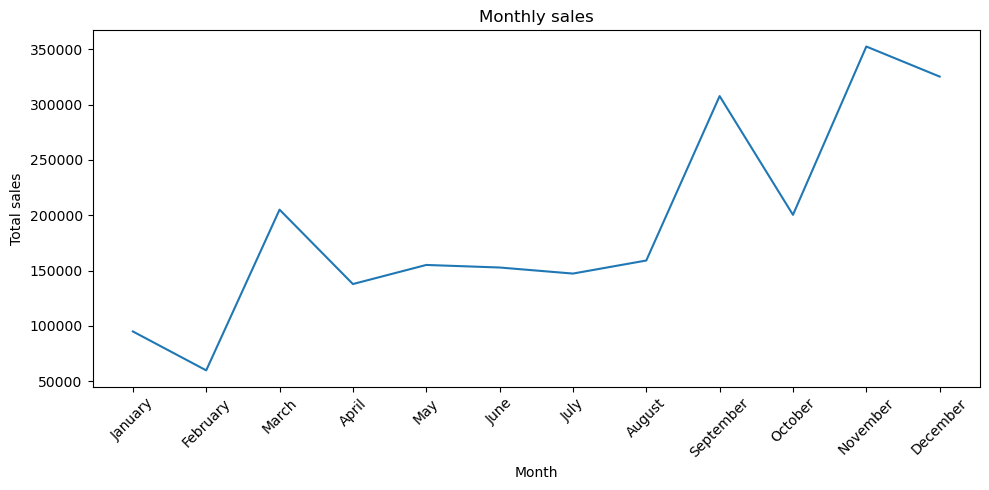

In [17]:
df["Month"] = df["Order Date"].dt.month_name()
month_order = ["January","February","March","April","May",'June','July','August','September','October',"November",'December']
monthly_sales = df.groupby("Month")["Sales"].sum().reindex(month_order)
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values)



plt.title("Monthly sales")
plt.xlabel("Month")
plt.ylabel("Total sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

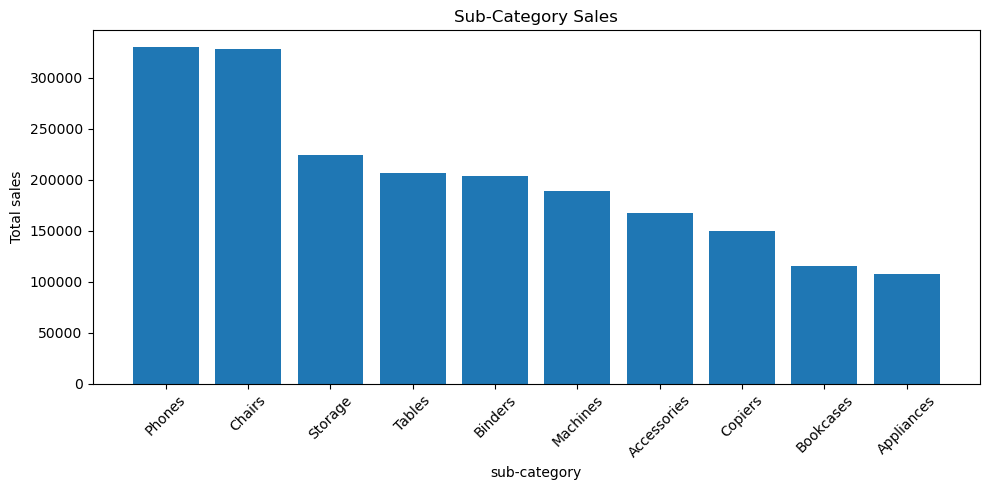

In [18]:
sub_category_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(sub_category_sales.index, sub_category_sales.values)



plt.title("Sub-Category Sales")
plt.xlabel("sub-category")
plt.ylabel("Total sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
